Nithin S

221IT085



In [28]:
!pip -q install qiskit
!pip -q install qiskit-ibm-runtime
!pip -q install qiskit_aer
!pip -q install qiskit[visualization]
!pip -q install pylatexenc
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
from math import pi, sqrt
from qiskit.visualization import plot_bloch_multivector, plot_histogram
import matplotlib.pyplot as plt

### Q1:  Explain the teleportation concept in detail by the experiment.

### Explanation:
Quantum teleportation transfers a qubit's state `|ψ>` from Alice to Bob without sending the physical qubit.


We use:
- **q0**: Alice’s qubit with state `|ψ>` (prepared here using an X gate for |1⟩ state).

- **q1**: Alice’s half of an entangled pair.

- **q2**: Bob’s half of an entangled pair.

Steps:
1. Prepare `|ψ>` on q0.

2. Create an entangled pair between q1 and q2 (`H` on q1, `CX(q1→q2)`).

3. Alice does a Bell measurement on q0 and q1 (`CX(q0→q1)`, `H(q0)`, measure q0, q1).

4. Based on Alice’s two classical bits, Bob applies corrections to q2:
   - If second bit = 1 → Apply X to q2 (`CX(q1→q2)` simulates this in our circuit).

   - If first bit = 1 → Apply Z to q2 (`CZ(q0→q2)` simulates this).
   
5. Measure q2 — this should match the original `|ψ>`.


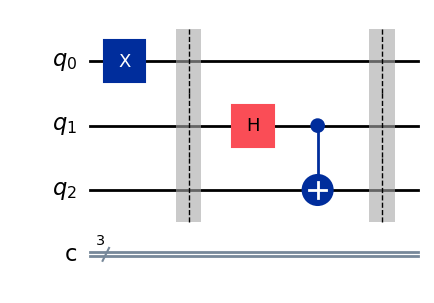

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt

# Create circuit with 3 qubits and 3 classical bits
qc = QuantumCircuit(3, 3)

# Prepare |ψ> on q0 (here |1>)
qc.x(0)
qc.barrier()

# Create entanglement between q1 and q2
qc.h(1)
qc.cx(1, 2)
qc.barrier()

qc.draw('mpl')


### Q2. Creating a circuit that works on a Quantum Register with 3 Qubits.

### Explanation:

We now add the Bell measurement part and show how Alice's two classical bits are obtained.

Process:

- Apply `CX(q0→q1)` and `H(q0)` for Bell measurement.

- Measure q0 and q1 into classical bits c0 and c1.


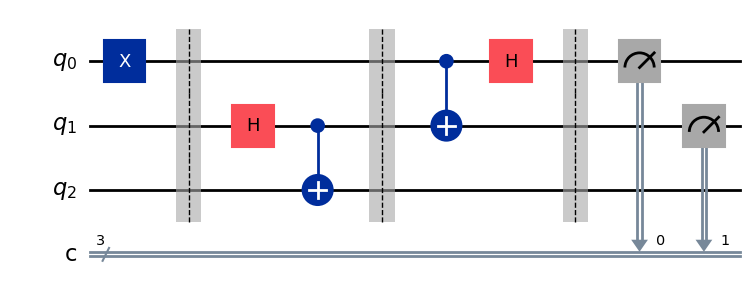

In [26]:
# Bell measurement
qc.cx(0, 1)
qc.h(0)
qc.barrier()

# Measure Alice's qubits into c0 and c1
qc.measure([0, 1], [0, 1])

qc.draw('mpl')


#### Q3. Write a code for the measurement of the Circuit

### Explanation:

Finally, we apply Bob’s corrections based on Alice’s bits and measure Bob’s qubit:

- `CX(q1→q2)` applies X to q2 if c1 = 1.

- `CZ(q0→q2)` applies Z to q2 if c0 = 1.

- Measure q2 to verify teleportation.

Then run the circuit on a simulator and plot the measurement histogram.


Measurement results: {'110': 266, '100': 276, '101': 218, '111': 264}


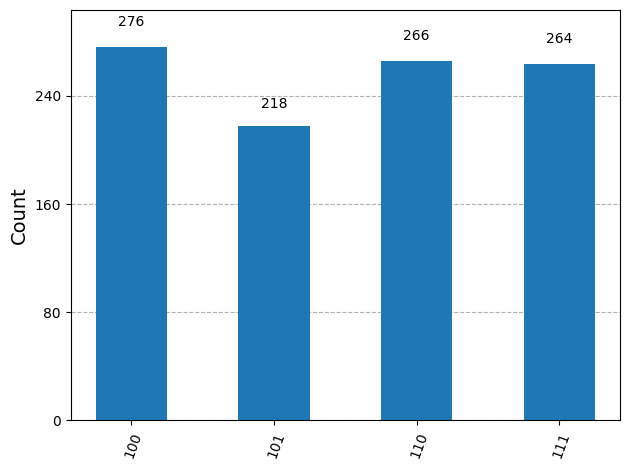

In [27]:
# Bob's conditional corrections
qc.cx(1, 2)
qc.cz(0, 2)
qc.barrier()

# Measure Bob's qubit
qc.measure([2], [2])
qc.draw('mpl')

# Run the circuit
backend = AerSimulator(method="automatic")
circuit = transpile(qc, backend)
result = backend.run(circuit, shots=1024).result()
count = result.get_counts()

print("Measurement results:", count)
plot_histogram(count)
